#### Import modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
text_data=pd.read_csv('../../data/text/raw_analyst_ratings.csv')

In [3]:
text_data

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
...,...,...,...,...,...,...
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,2011-08-29 00:00:00,ZX
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,2011-06-22 00:00:00,ZX
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,2011-06-21 00:00:00,ZX
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,2011-06-21 00:00:00,ZX


In [4]:
#basic inspection
print(text_data.info())
print(text_data.head())

<class 'pandas.DataFrame'>
RangeIndex: 1407328 entries, 0 to 1407327
Data columns (total 6 columns):
 #   Column      Non-Null Count    Dtype
---  ------      --------------    -----
 0   Unnamed: 0  1407328 non-null  int64
 1   headline    1407328 non-null  str  
 2   url         1407328 non-null  str  
 3   publisher   1407328 non-null  str  
 4   date        1407328 non-null  str  
 5   stock       1407328 non-null  str  
dtypes: int64(1), str(5)
memory usage: 64.4 MB
None
   Unnamed: 0                                           headline  \
0           0            Stocks That Hit 52-Week Highs On Friday   
1           1         Stocks That Hit 52-Week Highs On Wednesday   
2           2                      71 Biggest Movers From Friday   
3           3       46 Stocks Moving In Friday's Mid-Day Session   
4           4  B of A Securities Maintains Neutral on Agilent...   

                                                 url          publisher  \
0  https://www.benzinga.com/news/20

In [5]:
text_data['headline_len']=text_data['headline'].apply(len)
text_data['headline_len'].describe()

count    1.407328e+06
mean     7.312051e+01
std      4.073531e+01
min      3.000000e+00
25%      4.700000e+01
50%      6.400000e+01
75%      8.700000e+01
max      5.120000e+02
Name: headline_len, dtype: float64

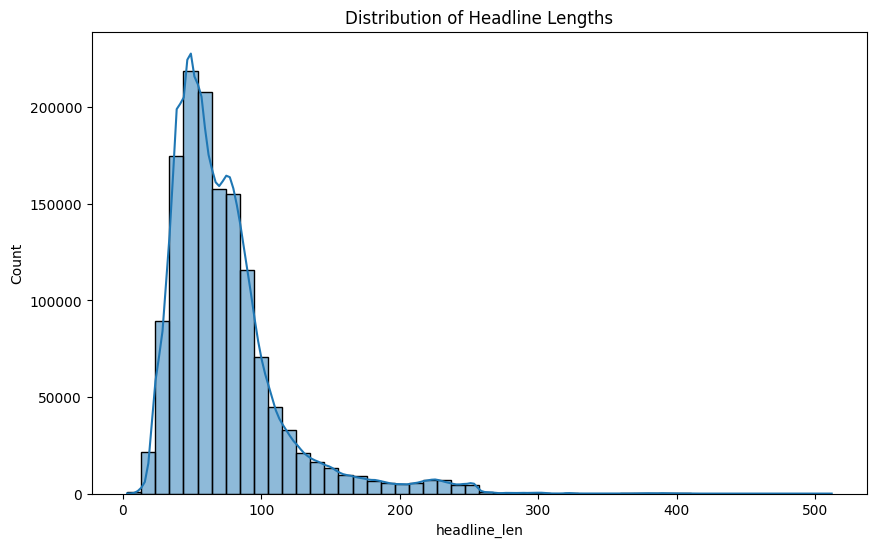

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(text_data['headline_len'], bins=50, kde=True)
plt.title('Distribution of Headline Lengths')
plt.show()

In [7]:
text_data.groupby('publisher')['headline'].count().sort_values(ascending=False)

publisher
Paul Quintaro             228373
Lisa Levin                186979
Benzinga Newsdesk         150484
Charles Gross              96732
Monica Gerson              82380
                           ...  
MyConstant Chris Roper         1
milesyoung                     1
Nat                            1
mjintertrader                  1
Adam Weiner                    1
Name: headline, Length: 1034, dtype: int64

In [8]:
text_data['date']=pd.to_datetime(text_data['date'], errors='coerce', utc=True)
text_data['date'] = text_data['date'].dt.tz_convert('US/Eastern')

In [9]:
text_data

,Unnamed: 0,headline,url,publisher,date,stock,headline_len
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87
...,...,...,...,...,...,...,...
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,NaT,ZX,38
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,NaT,ZX,52
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,NaT,ZX,56
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,NaT,ZX,54


In [10]:
text_data['hour'] = text_data['date'].dt.hour
text_data['day_of_week'] = text_data['date'].dt.day_name()
text_data['publication_date'] = text_data['date'].dt.date

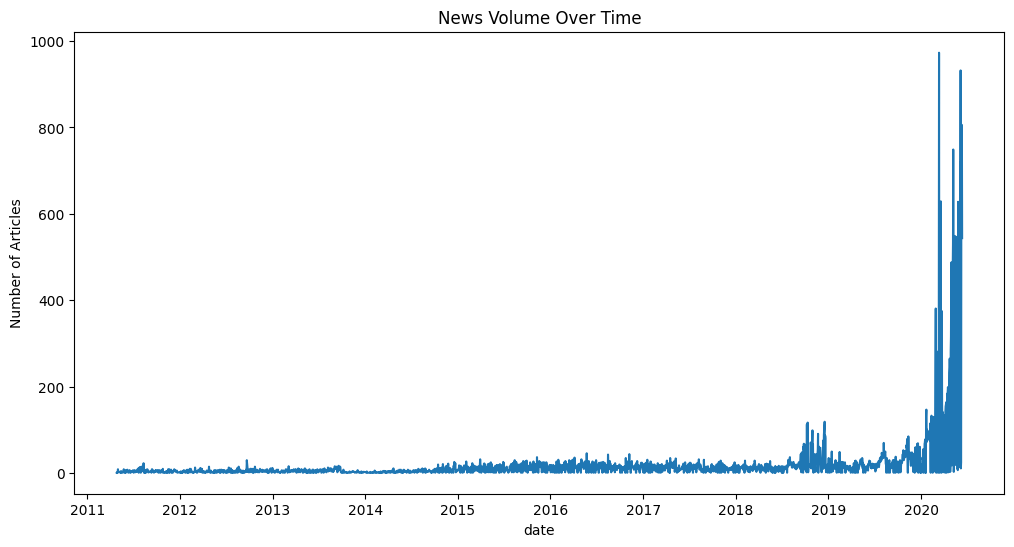

In [11]:
daily_news = text_data.groupby(text_data['date'].dt.date).size()

# Plot the timeline
plt.figure(figsize=(12, 6))
daily_news.plot()
plt.title('News Volume Over Time')
plt.ylabel('Number of Articles')
plt.show()

#### Topic modeling

In [12]:
import nltk
from nltk.corpus import stopwords
import re

In [13]:
stop_words=set(stopwords.words('english'))


In [14]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^\w\s]', '', text)
    tokens=text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

In [15]:
text_data['clean_headline']=text_data['headline'].apply(clean_text)

In [16]:
text_data

,Unnamed: 0,headline,url,publisher,date,stock,headline_len,hour,day_of_week,publication_date,clean_headline
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A,39,10.0,Friday,2020-06-05,stocks hit 52week highs friday
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A,42,10.0,Wednesday,2020-06-03,stocks hit 52week highs wednesday
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A,29,4.0,Tuesday,2020-05-26,71 biggest movers friday
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A,44,12.0,Friday,2020-05-22,46 stocks moving fridays midday session
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A,87,11.0,Friday,2020-05-22,b securities maintains neutral agilent technol...
...,...,...,...,...,...,...,...,...,...,...,...
1407323,1413844,Top Narrow Based Indexes For August 29,https://www.benzinga.com/news/11/08/1888782/to...,Monica Gerson,NaT,ZX,38,NaN,NaN,NaT,top narrow based indexes august 29
1407324,1413845,Recap: Wednesday's Top Percentage Gainers and ...,https://www.benzinga.com/news/earnings/11/06/1...,Benjamin Lee,NaT,ZX,52,NaN,NaN,NaT,recap wednesdays top percentage gainers losers
1407325,1413846,UPDATE: Oppenheimer Color on China Zenix Auto ...,https://www.benzinga.com/analyst-ratings/analy...,BenzingaStaffL,NaT,ZX,56,NaN,NaN,NaT,update oppenheimer color china zenix auto init...
1407326,1413847,Oppenheimer Initiates China Zenix At Outperfor...,https://www.benzinga.com/analyst-ratings/price...,Joe Young,NaT,ZX,54,NaN,NaN,NaT,oppenheimer initiates china zenix outperform 8 pt


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [18]:
vectorizer=TfidfVectorizer(max_features=1000, ngram_range=(1,2))
text_vec=vectorizer.fit_transform(text_data['clean_headline'])


In [19]:
features=vectorizer.get_feature_names_out()
print(features[:20])

['001' '002' '003' '004' '005' '006' '007' '008' '009' '01' '010' '011'
 '012' '013' '014' '015' '016' '017' '02' '020']


In [ ]:
from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(text_vec)


for index, topic in enumerate(lda.components_):
    print(f"Topic #{index + 1}:")
    print([features[i] for i in topic.argsort()[-10:]])
    print("-" * 20)

Topic #1:
['q1', 'q4', 'top', 'estimate', 'sees', 'sales', 'reports', 'eps', 'est', 'vs']
--------------------
Topic #2:
['companies', 'lower', 'market update', 'us', 'higher', 'says', 'trading', 'update', 'market', 'shares']
--------------------
Topic #3:
['premarket session', 'premarket', 'analyst', 'stocks', 'stocks moving', 'earnings scheduled', 'scheduled', 'moving', 'session', 'earnings']
--------------------
Topic #4:
['price', 'neutral', 'upgrades', 'target', 'downgrades', 'announces', 'raises', 'maintains', 'pt', 'buy']
--------------------
Topic #5:
['new', 'etf', 'yesterday', 'benzingas', 'biggest', 'movers', 'top', 'watch', 'etfs', 'stocks']
--------------------


In [22]:
topic_results = lda.transform(text_vec)
text_data['topic'] = topic_results.argmax(axis=1)

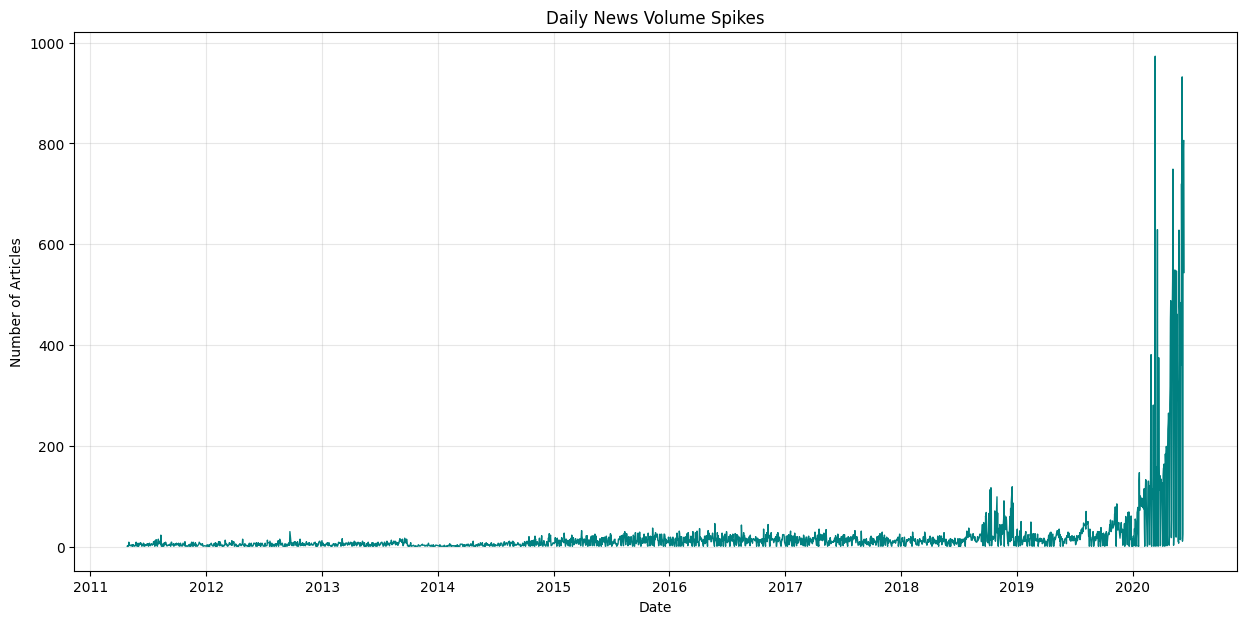

In [23]:
daily_counts = text_data.groupby(text_data['date'].dt.date).size()

plt.figure(figsize=(15, 7))
daily_counts.plot(color='teal', linewidth=1)
plt.title('Daily News Volume Spikes')
plt.xlabel('Date')
plt.ylabel('Number of Articles')
plt.grid(True, alpha=0.3)
plt.show()

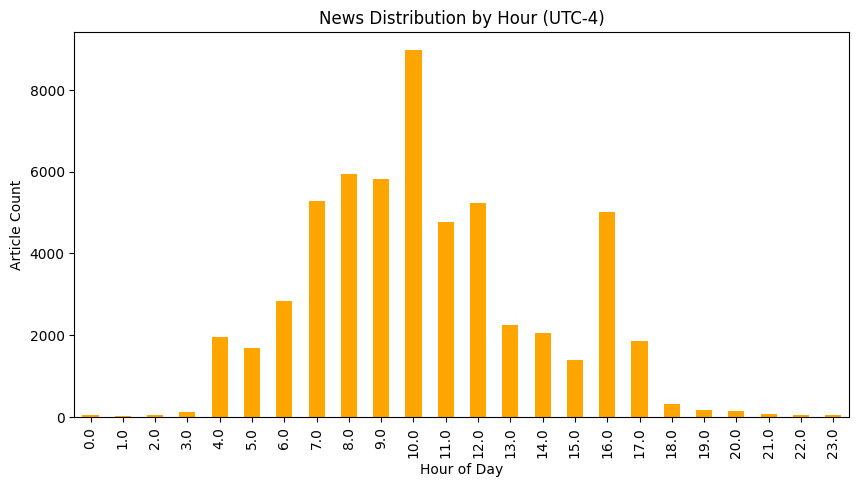

In [24]:
hourly_counts = text_data.groupby(text_data['date'].dt.hour).size()

plt.figure(figsize=(10, 5))
hourly_counts.plot(kind='bar', color='orange')
plt.title('News Distribution by Hour (UTC-4)')
plt.xlabel('Hour of Day')
plt.ylabel('Article Count')
plt.show()

In [26]:
def extract_domain(publisher):
    if '@' in str(publisher):
        return publisher.split('@')[-1]
    return publisher

text_data['publisher_clean'] = text_data['publisher'].apply(extract_domain)
print("\nTop Cleaned Domains/Publishers:")
print(text_data['publisher_clean'].value_counts().head(10))


Top Cleaned Domains/Publishers:
publisher_clean
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Name: count, dtype: int64


In [27]:

publisher_topic = pd.crosstab(text_data['publisher_clean'], text_data['topic'])
print(publisher_topic.loc[text_data['publisher_clean'].value_counts().head(5).index])

topic                  0      1      2      3      4
publisher_clean                                     
Paul Quintaro      75701  62878  27995  55662   6137
Lisa Levin         21397  50441  59750   3628  51763
Benzinga Newsdesk  34146  61978  13657  13137  27566
Charles Gross       6969  40035  18420  26921   4387
Monica Gerson      16602   8725  24356   6920  25777
